# Exercise 3

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def apply_boundary_conditions(c, N):
    c[0, :] = 0.0
    c[N, :] = 1.0
    return c

def analytical_solution(N):
    y = np.linspace(0.0, 1.0, N + 1)
    return y[:, None]

def jacobi(N, eps=1e-6, max_iter=10000):
    dx = 1.0 / N
    Ny, Nx = N, N  # y: 0..N ; x: 0..N-1 periodic

    c_old = np.zeros((Ny + 1, Nx))
    c_new = np.zeros_like(c_old)
    apply_boundary_conditions(c_old, Ny)
    apply_boundary_conditions(c_new, Ny)

    history = []
    it = 0
    max_delta = np.inf

    while it < max_iter and max_delta > eps:
        # interior update
        for j in range(1, Ny):
            for i in range(Nx):
                c_new[j, i] = 0.25 * (
                    c_old[j, (i - 1) % Nx] +
                    c_old[j, (i + 1) % Nx] +
                    c_old[j - 1, i] +
                    c_old[j + 1, i]
                )

        apply_boundary_conditions(c_new, Ny)

        max_delta = np.max(np.abs(c_new[1:Ny, :] - c_old[1:Ny, :]))
        history.append(max_delta)

        c_old[:, :] = c_new
        it += 1

    return c_old, dx, history, it

def gauss_seidel(N, eps=1e-6, max_iter=10000):
    dx = 1.0 / N
    Ny, Nx = N, N

    c = np.zeros((Ny + 1, Nx))
    apply_boundary_conditions(c, Ny)

    history = []
    it = 0
    max_delta = np.inf

    while it < max_iter and max_delta > eps:
        max_delta = 0.0

        # sweep (fixed j, increasing i)
        for j in range(1, Ny):
            for i in range(Nx):
                old = c[j, i]
                left  = c[j, (i - 1) % Nx]   # new
                right = c[j, (i + 1) % Nx]   # old
                down  = c[j - 1, i]          # new
                up    = c[j + 1, i]          # old
                c[j, i] = 0.25 * (left + right + down + up)

                delta = abs(c[j, i] - old)
                if delta > max_delta:
                    max_delta = delta

        apply_boundary_conditions(c, Ny)
        history.append(max_delta)
        it += 1

    return c, dx, history, it

def sor(N, omega=1.8, eps=1e-6, max_iter=10000):
    dx = 1.0 / N
    Ny, Nx = N, N

    c = np.zeros((Ny + 1, Nx))
    apply_boundary_conditions(c, Ny)

    history = []
    it = 0
    max_delta = np.inf

    while it < max_iter and max_delta > eps:
        max_delta = 0.0

        for j in range(1, Ny):
            for i in range(Nx):
                old = c[j, i]

                left  = c[j, (i - 1) % Nx]   # new
                right = c[j, (i + 1) % Nx]   # old
                down  = c[j - 1, i]          # new
                up    = c[j + 1, i]          # old

                gs_value = 0.25 * (left + right + down + up)
                c[j, i] = omega * gs_value + (1.0 - omega) * old

                delta = abs(c[j, i] - old)
                if delta > max_delta:
                    max_delta = delta

        apply_boundary_conditions(c, Ny)
        history.append(max_delta)
        it += 1

    return c, dx, history, it

## Question H

N=50, eps=1e-06
Jacobi      iterations=  6528, L_inf error vs c(y)=y: 1.012e-03
GaussSeidel iterations=  3629, L_inf error vs c(y)=y: 5.055e-04
SOR(ω=1.8)  iterations=   530, L_inf error vs c(y)=y: 5.454e-05


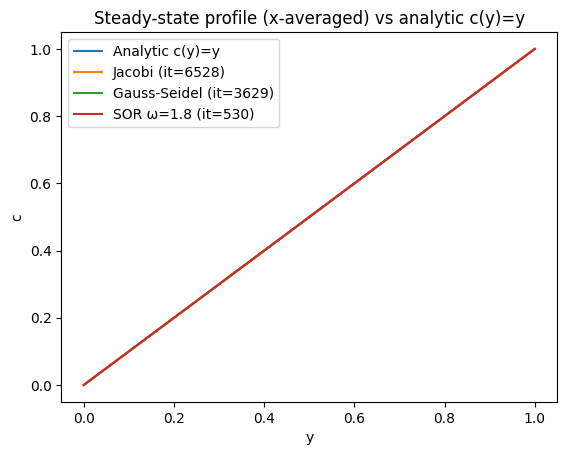

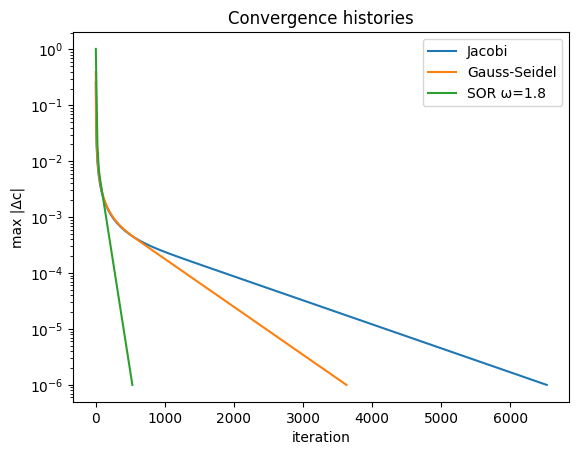

In [8]:
N = 50
eps = 1e-6
max_iter = 20000

c_exact = analytical_solution(N)

c_j, dx, h_j, it_j = jacobi(N, eps, max_iter)
c_g, dx, h_g, it_g = gauss_seidel(N, eps, max_iter)
c_s, dx, h_s, it_s = sor(N, omega=1.8, eps=eps, max_iter=max_iter)

# Errors vs analytic
err_j = np.max(np.abs(c_j - c_exact))
err_g = np.max(np.abs(c_g - c_exact))
err_s = np.max(np.abs(c_s - c_exact))

print(f"N={N}, eps={eps}")
print(f"Jacobi      iterations={it_j:6d}, L_inf error vs c(y)=y: {err_j:.3e}")
print(f"GaussSeidel iterations={it_g:6d}, L_inf error vs c(y)=y: {err_g:.3e}")
print(rf"SOR($\\omega$=1.8)  iterations={it_s:6d}, L_inf error vs c(y)=y: {err_s:.3e}")

# Plot one solution and analytic profile
y = np.linspace(0.0, 1.0, N + 1)
plt.plot(y, c_exact[:, 0], label="Analytic c(y)=y")
plt.plot(y, np.mean(c_j, axis=1), label=f"Jacobi (it={it_j})")
plt.plot(y, np.mean(c_g, axis=1), label=f"Gauss-Seidel (it={it_g})")
plt.plot(y, np.mean(c_s, axis=1), label=rf"SOR $\\omega$=1.8 (it={it_s})")
plt.xlabel("y")
plt.ylabel("c")
plt.title("Steady-state profile (x-averaged) vs analytic c(y)=y")
plt.legend()
plt.show()

# Convergence histories
plt.plot(h_j, label="Jacobi")
plt.plot(h_g, label="Gauss-Seidel")
plt.plot(h_s, label=r"SOR $\\omega$=1.8")
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("max |$\\Delta$ c|")
plt.title("Convergence histories")
plt.legend()
plt.show()

## Question I

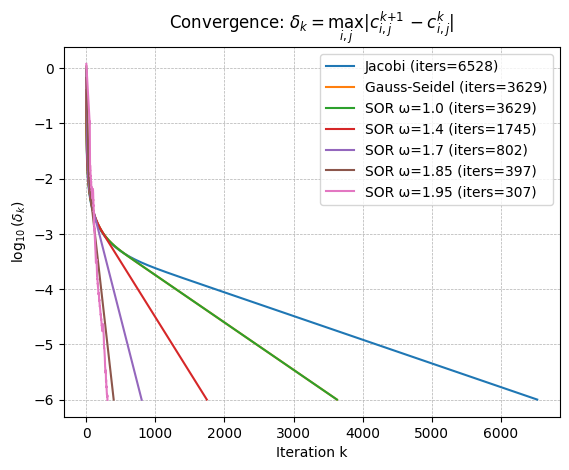

In [9]:
def plot_convergence_histories(N=50, eps=1e-6, max_iter=20000, omegas=(1.0, 1.4, 1.7, 1.85, 1.95)):
    _, _, h_j, it_j = jacobi(N, eps, max_iter)
    _, _, h_g, it_g = gauss_seidel(N, eps, max_iter)

    plt.figure()
    plt.plot(np.arange(len(h_j)), np.log10(h_j), label=f"Jacobi (iters={it_j})")
    plt.plot(np.arange(len(h_g)), np.log10(h_g), label=f"Gauss-Seidel (iters={it_g})")

    for w in omegas:
        _, _, h_s, it_s = sor(N, omega=w, eps=eps, max_iter=max_iter)
        plt.plot(np.arange(len(h_s)), np.log10(h_s), label=rf"SOR $\\omega$={w} (iters={it_s})")

    plt.xlabel("Iteration k")
    plt.ylabel(r"$\log_{10}(\delta_k)$")
    plt.title(r"Convergence: $\delta_k = \max_{i,j}|c^{k+1}_{i,j}-c^k_{i,j}|$")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend()
    plt.show()

plot_convergence_histories()

## Question J

In [16]:
# N = 50 with original SOR method (NOTE: VERY SLOW)
def find_optimal_omega(N, eps=1e-6, max_iter=20000,
                       omega_min=1.0, omega_max=1.99, n_samples=60):
    omegas = np.linspace(omega_min, omega_max, n_samples)
    best = {"omega": None, "iters": np.inf, "final_delta": None}

    for w in omegas:
        _, _, hist, iters = sor(N, omega=float(w), eps=eps, max_iter=max_iter)
        final_delta = hist[-1] if len(hist) else np.inf

        # only accept converged runs
        if final_delta < eps and iters < best["iters"]:
            best = {"omega": float(w), "iters": int(iters), "final_delta": float(final_delta)}

    return best, omegas

best, omegas = find_optimal_omega(N=50, eps=1e-6, n_samples=50)
print(best)

{'omega': 1.9293877551020406, 'iters': 227, 'final_delta': 9.67527927941969e-07}


In [14]:
# N varies with vectorized SOR method (NOTE: VERY SLOW)
def apply_bc(c, N):
    c[0, :] = 0.0
    c[N, :] = 1.0
    return c

def delta_max(c_new, c_old, N):
    return np.max(np.abs(c_new[1:N, :] - c_old[1:N, :]))

def sor_redblack_iters(N, omega, eps=1e-6, max_iter=20000):
    if not (0.0 < omega < 2.0):
        return max_iter

    Ny, Nx = N, N
    c = np.zeros((Ny + 1, Nx), dtype=float)
    apply_bc(c, Ny)

    jj, ii = np.indices((Ny + 1, Nx))
    red = ((ii + jj) % 2 == 0)
    black = ~red

    red[0, :] = red[Ny, :] = False
    black[0, :] = black[Ny, :] = False

    for it in range(1, max_iter + 1):
        c_prev = c.copy()

        left  = np.roll(c,  1, axis=1)
        right = np.roll(c, -1, axis=1)
        down  = np.roll(c,  1, axis=0)
        up    = np.roll(c, -1, axis=0)

        gs = 0.25 * (left + right + down + up)
        c[red] = (1.0 - omega) * c[red] + omega * gs[red]
        apply_bc(c, Ny)

        left  = np.roll(c,  1, axis=1)
        right = np.roll(c, -1, axis=1)
        down  = np.roll(c,  1, axis=0)
        up    = np.roll(c, -1, axis=0)

        gs = 0.25 * (left + right + down + up)
        c[black] = (1.0 - omega) * c[black] + omega * gs[black]
        apply_bc(c, Ny)
        d = delta_max(c, c_prev, Ny)
        if d < eps:
            return it

    return max_iter

def scan_omega_vs_N(N_list, omegas, eps=1e-6, max_iter=20000):
    iters_map = {}
    omega_opt = {}
    for N in N_list:
        iters = np.array([sor_redblack_iters(N, w, eps=eps, max_iter=max_iter) for w in omegas], dtype=int)
        iters_map[N] = iters
        omega_opt[N] = omegas[np.argmin(iters)]
    return iters_map, omega_opt

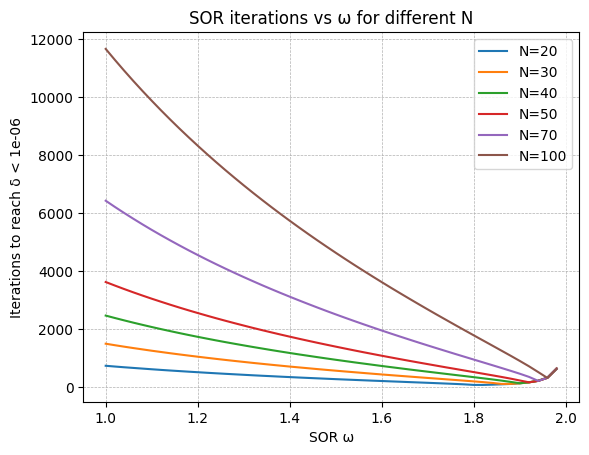

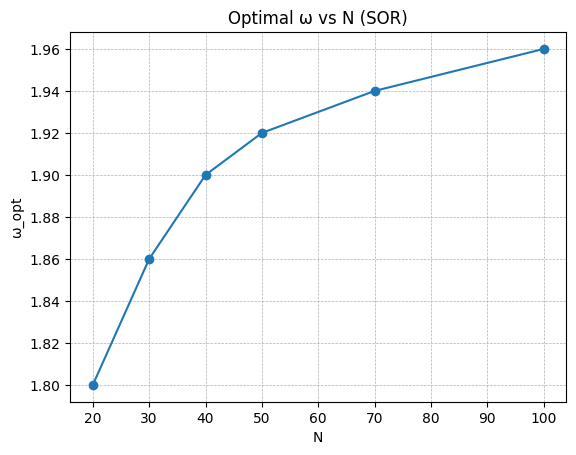

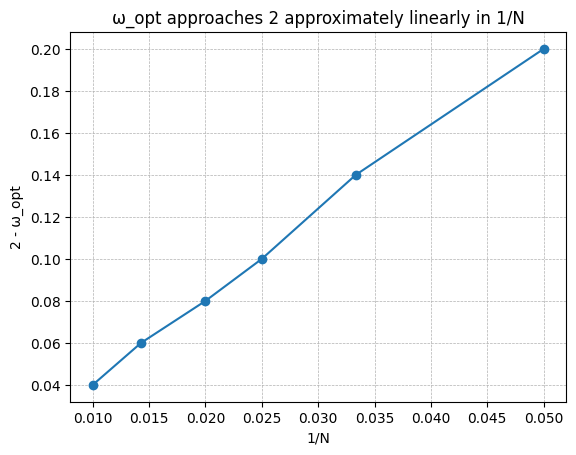

N= 20  ω_opt≈1.8000  min iters=68
N= 30  ω_opt≈1.8600  min iters=103
N= 40  ω_opt≈1.9000  min iters=126
N= 50  ω_opt≈1.9200  min iters=158
N= 70  ω_opt≈1.9400  min iters=207
N=100  ω_opt≈1.9600  min iters=309


In [15]:
N_list = [20, 30, 40, 50, 70, 100]
omegas = np.linspace(1.0, 1.98, 50)
eps = 1e-6
max_iter = 20000

iters_map, omega_opt = scan_omega_vs_N(N_list, omegas, eps=eps, max_iter=max_iter)

plt.figure()
for N in N_list:
    plt.plot(omegas, iters_map[N], label=f"N={N}")
plt.xlabel(r"SOR $\\omega$")
plt.ylabel(rf"Iterations to reach $\\delta$ < {eps:g}")
plt.title(r"SOR iterations vs $\\omega$ for different N")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

Ns = np.array(N_list, dtype=float)
wopt = np.array([omega_opt[N] for N in N_list], dtype=float)

plt.figure()
plt.plot(Ns, wopt, marker="o")
plt.xlabel("N")
plt.ylabel(r"$\\omega$_opt")
plt.title(r"Optimal $\\omega$ vs N (SOR)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

plt.figure()
plt.plot(1.0/Ns, 2.0 - wopt, marker="o")
plt.xlabel("1/N")
plt.ylabel(r"2 - $\\omega$_opt")
plt.title(r"$\\omega$_opt approaches 2 approximately linearly in 1/N")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

for N in N_list:
    print(rf"N={N:3d}  $\\omega$_opt={omega_opt[N]:.4f}  min iters={iters_map[N].min()}")

## Question K

To include objects that act as sinks, we add a mask array `obj` with the same shape as the concentration field.

* `obj[j,i] = True`: grid point is part of an object, so the concentration fixed to 0.
* During the iteration we skip the update at those points.
* After each sweep we enforce both the physical boundary conditions and `c=0` inside the objects.

In [19]:
def apply_bc_and_objects(c, obj, N):
    c[0, :] = 0.0
    c[N, :] = 1.0
    c[obj] = 0.0
    return c

def make_rectangle_object(N, x0, x1, y0, y1):
    Ny, Nx = N, N
    obj = np.zeros((Ny + 1, Nx), dtype=bool)

    i0 = int(x0 * Nx); i1 = int(x1 * Nx)
    j0 = int(y0 * Ny); j1 = int(y1 * Ny)

    obj[j0:j1, i0:i1] = True
    return obj

def sor_with_objects(N, omega, eps=1e-6, max_iter=20000, obj=None):
    Ny, Nx = N, N
    if obj is None:
        obj = np.zeros((Ny + 1, Nx), dtype=bool)

    c = np.zeros((Ny + 1, Nx))
    apply_bc_and_objects(c, obj, Ny)

    history = []
    for it in range(max_iter):
        max_delta = 0.0

        for j in range(1, Ny):
            for i in range(Nx):
                if obj[j, i]:
                    continue

                old = c[j, i]

                left  = c[j, (i - 1) % Nx]
                right = c[j, (i + 1) % Nx]
                down  = c[j - 1, i]
                up    = c[j + 1, i]

                gs = 0.25 * (left + right + down + up)
                new = omega * gs + (1 - omega) * old
                c[j, i] = new

                max_delta = max(max_delta, abs(new - old))

        apply_bc_and_objects(c, obj, Ny)
        history.append(max_delta)

        if max_delta < eps:
            return c, history, it + 1

    return c, history, max_iter

In [20]:
N = 50
eps = 1e-6

# baseline
c0, h0, it0 = sor_with_objects(N, omega=1.8, eps=eps)

# with a rectangular sink
obj = make_rectangle_object(N, 0.35, 0.65, 0.35, 0.55)
c1, h1, it1 = sor_with_objects(N, omega=1.8, eps=eps, obj=obj)

print("Iterations without object:", it0)
print("Iterations with object:", it1)

Iterations without object: 530
Iterations with object: 242


In [21]:
def find_best_omega(N, omegas, eps, obj=None):
    best_w, best_it = None, 10**9
    for w in omegas:
        _, hist, it = sor_with_objects(N, w, eps=eps, obj=obj)
        if hist[-1] < eps and it < best_it:
            best_it = it
            best_w = w
    return best_w, best_it

omegas = np.linspace(1.0, 1.98, 40)

w0, it0 = find_best_omega(N, omegas, eps, obj=None)
w1, it1 = find_best_omega(N, omegas, eps, obj=obj)

print(r"No object:  $\\omega$_opt =", w0, "iterations =", it0)
print(r"With object: $\\omega$_opt =", w1, "iterations =", it1)

No object:  ω_opt = 1.9297435897435897 iterations = 228
With object: ω_opt = 1.8794871794871795 iterations = 141


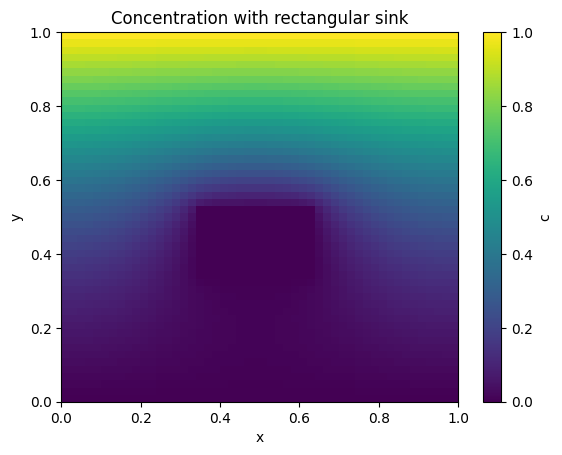

In [22]:
import matplotlib.pyplot as plt

plt.imshow(c1, origin="lower", extent=(0,1,0,1), aspect="auto")
plt.colorbar(label="c")
plt.title("Concentration with rectangular sink")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Question L

In [ ]:
def apply_bc(c, N):
    c[0, :] = 0.0 # y=0
    c[N, :] = 1.0 # y=1
    return c

def make_rectangle_object(N, x0, x1, y0, y1):
    Ny, Nx = N, N
    obj = np.zeros((Ny + 1, Nx), dtype=bool)
    i0 = int(np.floor(x0 * Nx)); i1 = int(np.ceil(x1 * Nx))
    j0 = int(np.floor(y0 * Ny)); j1 = int(np.ceil(y1 * Ny))
    i0 = np.clip(i0, 0, Nx-1); i1 = np.clip(i1, 0, Nx)
    j0 = np.clip(j0, 0, Ny);   j1 = np.clip(j1, 0, Ny+1)
    obj[j0:j1, i0:i1] = True
    return obj

def sor_insulator(N, obj, omega=1.85, eps=1e-6, max_iter=20000):
    Ny, Nx = N, N
    c = np.zeros((Ny + 1, Nx), dtype=float)
    apply_bc(c, Ny)

    for it in range(1, max_iter + 1):
        max_delta = 0.0

        for j in range(1, Ny):
            for i in range(Nx):
                if obj[j, i]:
                    continue # solid

                old = c[j, i]

                def nb(jn, in_):
                    in_ %= Nx
                    if obj[jn, in_]:
                        return c[j, i]
                    return c[jn, in_]

                left  = nb(j, i - 1)
                right = nb(j, i + 1)
                down  = nb(j - 1, i)
                up    = nb(j + 1, i)

                gs = 0.25 * (left + right + down + up)
                new = omega * gs + (1.0 - omega) * old
                c[j, i] = new

                max_delta = max(max_delta, abs(new - old))

        apply_bc(c, Ny)
        if max_delta < eps:
            return c, it

    return c, max_iter

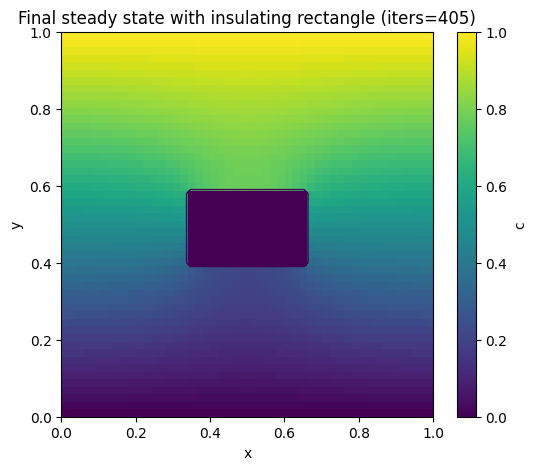

In [24]:
N = 50
obj = make_rectangle_object(N, x0=0.35, x1=0.65, y0=0.40, y1=0.60)

c_final, iters = sor_insulator(N, obj, omega=1.85, eps=1e-6)

x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N + 1)

plt.figure(figsize=(6,5))
plt.imshow(c_final, origin="lower", extent=(0,1,0,1), aspect="auto")
plt.colorbar(label="c")
plt.contour(x, y, obj.astype(float), levels=[0.5], linewidths=1)  # object outline
plt.title(f"Final steady state with insulating rectangle (iters={iters})")
plt.xlabel("x")
plt.ylabel("y")
plt.show()